<a href="https://colab.research.google.com/github/michelleshumilov1998-ai/Ozone-Air-Quality-Analysis/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
# ============================================================
# 1. Environment Setup & Library Imports
# ============================================================
!pip -q install -U openpyxl python-pptx

import pandas as pd
import numpy as np
import io
import openpyxl
from openpyxl.styles import numbers
from google.colab import files
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer

# Global Configurations
pd.set_option('future.no_silent_downcasting', True)

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# ============================================================
# 2. Manual Data Upload
# ============================================================
# Uploading heterogeneous datasets provided by the Environmental Association
uploaded = files.upload()
names = list(uploaded.keys())

Saving Group, 06-11-2025 09-03-16.xlsx to Group, 06-11-2025 09-03-16.xlsx
Saving SVS O3 Temp 2017-2025.xlsx to SVS O3 Temp 2017-2025.xlsx


In [ ]:
# ============================================================
# 3. Dynamic Schema Detection
# ============================================================
# Reading files with 3-level MultiIndex headers [cite: 77, 136]
df_a = pd.read_excel(io.BytesIO(uploaded[names[0]]), header=[0,1,2], engine="openpyxl")
df_b = pd.read_excel(io.BytesIO(uploaded[names[1]]), header=[0,1,2], engine="openpyxl")

# Helper functions to identify 'Date & Time' column across different MultiIndex structures
def find_dt_col_df1_style(df):
    """Finds Date & Time when located at the 3rd level of the MultiIndex."""
    for c in df.columns:
        if str(c[2]).strip() == "Date & Time":
            return c
    return None

def find_dt_col_df2_style(df):
    """Finds Date & Time when located at the 1st level of the MultiIndex."""
    for c in df.columns:
        if str(c[0]).strip() == "Date & Time":
            return c
    return None

# Assigning dataframes based on detected style
dt_a1 = find_dt_col_df1_style(df_a)
if dt_a1 is not None:
    df1, dt1 = df_a, dt_a1
    df2 = df_b
else:
    df1, dt1 = df_b, dt_b1
    df2 = df_a

dt2 = find_dt_col_df2_style(df2)

Phase 2: Data Splitting and Merging

In [ ]:
# ============================================================
# 4. Data Wrangling: Splitting, Merging, and Coalescing
# ============================================================

def split_time_and_meta(df, dt_col, dayfirst=True):
    """Separates hourly time-series data from summary/meta rows (e.g., Avg, Max)."""
    raw = df[dt_col]
    parsed = pd.to_datetime(raw, errors="coerce", dayfirst=dayfirst)
    time_mask = parsed.notna()

    time_df = df.loc[time_mask].copy()
    time_df.index = parsed.loc[time_mask]
    time_df = time_df.drop(columns=[dt_col]).sort_index()

    meta_df = df.loc[~time_mask].copy()
    return time_df, meta_df

# Splitting datasets
df1_time, df1_meta = split_time_and_meta(df1, dt1)
df2_time, df2_meta = split_time_and_meta(df2, dt2)

# Performing outer join to ensure no hourly data is lost
combined_time = pd.concat([df1_time, df2_time], axis=1, join="outer")

def coalesce_duplicate_columns(df):
    """Consolidates identical columns from different sources by filling missing values."""
    out = {}
    for col in df.columns.unique():
        block = df.loc[:, df.columns == col]
        out[col] = block.bfill(axis=1).iloc[:, 0]
    return pd.DataFrame(out, index=df.index)

merged_time = coalesce_duplicate_columns(combined_time)

# Reconstructing the 3-level MultiIndex (Station, Measure, Unit)
measures_a = df_a.iloc[0]
units_a    = df_a.iloc[1]

new_cols = []
for col in merged_time.columns:
    col0, col1 = str(col[0]), str(col[1])
    if col0.startswith("Group:") or "Unnamed" in col1:
        station = str(col[2]).strip()
        measure = str(measures_a.get(col, "")).strip()
        unit    = str(units_a.get(col, "")).strip()
    else:
        station, measure, unit = str(col[0]).strip(), str(col[1]).strip(), str(col[2]).strip()
    new_cols.append((station, measure, unit))

hourly = merged_time.copy()
hourly.columns = pd.MultiIndex.from_tuples(new_cols)
hourly.index = pd.to_datetime(hourly.index, errors="coerce").floor("h")

# Sorting columns by Station to ensure analytical continuity
station_order = []
for s, m, u in hourly.columns:
    if s not in station_order: station_order.append(s)

new_order = []
for s in station_order:
    new_order.extend([c for c in hourly.columns if c[0] == s])

hourly = hourly.loc[:, new_order]
meta_all = pd.concat([df1_meta, df2_meta], axis=0)

In [ ]:
# ============================================================
# 5. Exporting Results & Final Validation
# ============================================================
out_path = "/content/merged_output.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    hourly.index.name = "Date & Time"
    hourly.to_excel(writer, sheet_name="Hourly", merge_cells=True)
    meta_all.to_excel(writer, sheet_name="Summary", merge_cells=False)

# Quick validation: Checking consistency of TEMP measurements across stations
temp_cols = [c for c in hourly.columns if str(c[1]).strip() == "TEMP"]
print(f"Successfully merged {len(hourly.columns)} columns.")
print(f"Validation: Found {len(temp_cols)} temperature monitoring columns.")

files.download(out_path)

Successfully merged 71 columns.
Validation: Found 15 temperature monitoring columns.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 6. Preprocessing & Data Sanitization
# ============================================================

# Global Imputation Constraints
THRESHOLD = 0.40  # Max 40% missing values allowed for imputation
MAX_GAP = 3       # Max consecutive missing hours to fill (Scientific Accuracy)

# Mapping Measures to Algorithms
MEAS_LR   = {"TEMP", "SVS"}  # Features for Linear Regression imputation
MEAS_KNN  = {"WDD", "WDS"}   # Features for K-Nearest Neighbors imputation
MEAS_SKIP = {"O3"}           # Ozone (Target) - Original measurements only

# Comprehensive list of invalid string indicators in raw data
INVALID_VALUES = [
    "NoData", "OffScan", "Span", "Calib", "<Samp",
    "NoData.1", "NoData.2", "NoData.3",
    "OffScan.1", "Span.1", "Calib.1",
    "", " ", "nan", "NaN", "None"
]

# 1) Cleaning: Replace invalid strings with NaN and convert all columns to numeric
hourly_clean = hourly.replace(INVALID_VALUES, np.nan).infer_objects(copy=False)
hourly_clean = hourly_clean.apply(pd.to_numeric, errors="coerce")

# 2) Time-based Feature Preparation (without mutating the original index)
# Extracting hourly timestamps for later feature extraction (e.g., Hour of Day)
dt_index = pd.to_datetime(hourly_clean.index, errors="coerce").floor("h")
valid_time_rows = dt_index.notna()

print(f"Data cleaned. Shape: {hourly_clean.shape}")

Data cleaned. Shape: (78168, 71)


In [38]:
# ============================================================
# 7. Imputation Strategy & Gap Constraints
# ============================================================

# 0) CRITICAL: Sort the MultiIndex columns to fix PerformanceWarning and ensure uniqueness
# This allows Pandas to index the data much faster and more reliably.
hourly_clean = hourly_clean.sort_index(axis=1)

# 1) Evaluate 'Touchable' columns
# Using .isna().mean() on a sorted, unique index to avoid ambiguity
missing_ratio = hourly_clean.isna().mean()

def get_measure_type(col):
    """Extracts the measure type (e.g., O3, TEMP) from the MultiIndex column."""
    return str(col[1]).strip()

touchable_cols = {}
# We use .columns.unique() to ensure we only process each distinct column label once
for col in hourly_clean.columns.unique():
    meas = get_measure_type(col)
    if meas in MEAS_SKIP:
        touchable_cols[col] = False
    else:
        # Accessing the first value [0] in case duplicates still exist in the ratio Series
        ratio = missing_ratio[col]
        current_ratio = ratio.iloc[0] if isinstance(ratio, pd.Series) else ratio
        touchable_cols[col] = (current_ratio <= THRESHOLD)

# 2) Create Imputation Masks
def get_allowed_gap_mask(series: pd.Series, max_allowed: int) -> pd.Series:
    """Identifies missing value sequences that are short enough to be safely imputed."""
    # Ensure we are working with a 1D array to avoid "ambiguous truth value" error
    if isinstance(series, pd.DataFrame):
        # If duplicates exist, we take the first column
        series = series.iloc[:, 0]

    is_na = series.isna().to_numpy()
    allowed = np.zeros_like(is_na, dtype=bool)

    i, n = 0, len(is_na)
    while i < n:
        if not is_na[i]:
            i += 1
            continue
        j = i
        while j < n and is_na[j]:
            j += 1

        gap_length = j - i
        if gap_length <= max_allowed:
            allowed[i:j] = True
        i = j

    return pd.Series(allowed, index=series.index)

# Generate a mask for every unique column
allowed_masks = {}
for col in hourly_clean.columns.unique():
    # We pass hourly_clean[col] which is now guaranteed to be handled inside the function
    allowed_masks[col] = get_allowed_gap_mask(hourly_clean[col], MAX_GAP)

print(f"Imputation strategy defined. {sum(touchable_cols.values())} unique columns qualify for processing.")

Imputation strategy defined. 13 unique columns qualify for processing.


In [39]:
# ============================================================
# 8. Linear Regression Imputation (TEMP & SVS)
# ============================================================

def lr_impute_one_column(df, col, dt_index, allowed_mask, valid_rows_mask):
    """
    Imputes missing values using Linear Regression with numerical time as the feature.
    Only fills gaps that satisfy the MAX_GAP constraint.
    """
    y = df[col]

    # Ensure we are handling a Series (handles duplicate column names)
    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]

    # X-Feature: Convert timestamps to numerical values (nanoseconds since epoch)
    X_all = pd.Series(dt_index.view("int64"), index=df.index)

    # Train Mask: Rows with valid timestamps and existing data
    train_mask = valid_rows_mask & y.notna()
    if train_mask.sum() < 10:  # Minimum data requirement for a stable model
        return 0

    X_train = X_all.loc[train_mask].to_numpy().reshape(-1, 1)
    y_train = y.loc[train_mask].to_numpy()

    # Fit the linear trend
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prediction Mask: Rows with missing data that are within allowed gaps
    pred_mask = valid_rows_mask & y.isna() & allowed_mask
    if pred_mask.sum() == 0:
        return 0

    X_pred = X_all.loc[pred_mask].to_numpy().reshape(-1, 1)
    y_pred = model.predict(X_pred)

    # Apply predictions back to the dataframe
    df.loc[pred_mask, col] = y_pred
    return int(pred_mask.sum())

# Execute Imputation for LR-compatible measures
lr_filled_count = 0
hourly_imputed = hourly_clean.copy()

# Iterate over unique columns to apply the imputation strategy
for col in hourly_imputed.columns.unique():
    meas = get_measure_type(col)

    # Apply LR only for specific measures and qualified 'touchable' columns
    if meas in MEAS_LR and touchable_cols.get(col, False):
        count = lr_impute_one_column(
            hourly_imputed, col, dt_index, allowed_masks[col], valid_time_rows
        )
        lr_filled_count += count

print(f"Linear Regression imputation complete. Total cells filled: {lr_filled_count}")

Linear Regression imputation complete. Total cells filled: 385


In [40]:
# ============================================================
# 9. KNN Imputation for Wind Features (WDD & WDS)
# ============================================================

# 1) Time-based Feature Engineering
time_features = pd.DataFrame(index=hourly_imputed.index)
time_features["hour"] = dt_index.hour
time_features["dayofyear"] = dt_index.dayofyear
time_features = time_features.fillna(time_features.median(numeric_only=True))

# 2) Execution of KNN Imputation per Station
knn_filled_count = 0
stations = sorted(set(str(c[0]).strip() for c in hourly_imputed.columns))

for st in stations:
    cols_st = [c for c in hourly_imputed.columns if str(c[0]).strip() == st]

    targets = [c for c in cols_st if get_measure_type(c) in MEAS_KNN and touchable_cols.get(c, False)]
    if not targets:
        continue

    feat_cols = []
    temp_cols = [c for c in cols_st if get_measure_type(c) == "TEMP"]
    svs_cols  = [c for c in cols_st if get_measure_type(c) == "SVS"]

    if temp_cols: feat_cols.append(temp_cols[0])
    if svs_cols:  feat_cols.append(svs_cols[0])
    feat_cols.extend(targets)

    # Creating unique labels for concatenation
    X_raw = pd.concat([hourly_imputed[feat_cols], time_features], axis=1)
    X = X_raw.copy()
    X.columns = [f"{c[0]}_{c[1]}_{c[2]}" if isinstance(c, tuple) else str(c) for c in X.columns]

    # KNN Imputation
    imputer = KNNImputer(n_neighbors=5, weights="distance")
    X_imp = pd.DataFrame(imputer.fit_transform(X), index=X.index, columns=X.columns)

    # 3) Selective Imputation with 1D Enforcement
    for tgt in targets:
        tgt_str = f"{tgt[0]}_{tgt[1]}_{tgt[2]}"
        allowed = allowed_masks[tgt]

        # --- FIX: Ensure we have 1D arrays to prevent shape mismatch errors ---
        # If hourly_imputed[tgt] returns a DataFrame (due to duplicates), we take the first column
        y_col = hourly_imputed[tgt]
        if isinstance(y_col, pd.DataFrame):
            y_col = y_col.iloc[:, 0]

        is_na = y_col.isna().values.flatten()

        # Ensure 'allowed' is also treated as a flat 1D array
        is_allowed = allowed.values.flatten() if hasattr(allowed, "values") else np.array(allowed).flatten()

        # Create a boolean series with guaranteed 1D data
        mask = pd.Series(is_na & is_allowed, index=hourly_imputed.index)

        if mask.any():
            # Apply predicted values only to the specified mask
            predicted_values = X_imp.loc[mask, tgt_str].values
            hourly_imputed.loc[mask, tgt] = predicted_values
            knn_filled_count += int(mask.sum())

print(f"KNN Imputation complete. Total wind data cells filled: {knn_filled_count}")

KNN Imputation complete. Total wind data cells filled: 530


In [41]:
# ============================================================
# 10. Final Imputation Audit
# ============================================================
# This cell verifies that the KNN and LR imputations followed
# the scientific constraints (Max 3h gap and 40% threshold).

# 1) Calculate the expected number of filled cells based on our 'Allowed Masks'
total_allowed_missing = 0

# We filter columns that were eligible for KNN (WDD/WDS) and were 'touchable'
w_cols = [c for c in hourly_clean.columns.unique() if get_measure_type(c) in MEAS_KNN and touchable_cols.get(c, False)]

for c in w_cols:
    # Identify NaNs in the original data that were within allowed gaps (<= 3h)
    # Using .values to ensure 1D alignment and handle potential duplicates
    is_na = hourly_clean[c].isna().values.flatten() if isinstance(hourly_clean[c], pd.DataFrame) else hourly_clean[c].isna().values
    is_allowed = allowed_masks[c].values.flatten()

    total_allowed_missing += int((is_na & is_allowed).sum())

# 2) Display the Audit results
print(f"Audit Summary:")
print(f"-------------------------------------------")
print(f" - Total allowed missing cells (<= {MAX_GAP}h): {total_allowed_missing}")
print(f" - Actual cells filled during process: {knn_filled_count}")

# 3) Integrity Check: The number of filled cells must not exceed the allowed gaps
integrity_status = "Passed" if knn_filled_count <= total_allowed_missing else "Failed"
print(f" - Integrity Check: {integrity_status}")

if integrity_status == "Passed":
    print("\nSuccess: Imputation restricted to small gaps as per scientific protocol.")
else:
    print("\nWarning: Discrepancy detected in imputation counts. Review constraints.")

Audit Summary:
-------------------------------------------
 - Total allowed missing cells (<= 3h): 530
 - Actual cells filled during process: 530
 - Integrity Check: Passed

Success: Imputation restricted to small gaps as per scientific protocol.


In [42]:
# ============================================================
# 11. Imputation Integrity Check
# ============================================================

# 1) Wind Data (WDD/WDS) - Checking how many cells were filled
w_cols = [c for c in hourly_clean.columns.unique() if get_measure_type(c) in MEAS_KNN and touchable_cols.get(c, False)]

# We use .values.sum() to avoid shape errors with duplicate columns
before_nan_wind = hourly_clean[w_cols].isna().values.sum()
after_nan_wind  = hourly_imputed[w_cols].isna().values.sum()

print("Wind Features Check (WDD/WDS):")
print(f" - NaNs before imputation: {before_nan_wind}")
print(f" - NaNs after imputation:  {after_nan_wind}")
print(f" - Delta (cells filled):   {before_nan_wind - after_nan_wind}")

# 2) Ozone (O3) - CRITICAL: Ensuring zero changes to target variable
o3_cols = [c for c in hourly_imputed.columns.unique() if get_measure_type(c) == "O3"]

before_nan_o3 = hourly_clean[o3_cols].isna().values.sum()
after_nan_o3  = hourly_imputed[o3_cols].isna().values.sum()

print("\nTarget Variable Check (O3):")
print(f" - NaNs before (Original): {before_nan_o3}")
print(f" - NaNs after (Current):  {after_nan_o3}")
print(f" - Integrity Status: {'PASSED' if before_nan_o3 == after_nan_o3 else 'FAILED'}")

Wind Features Check (WDD/WDS):
 - NaNs before imputation: 52945
 - NaNs after imputation:  52415
 - Delta (cells filled):   530

Target Variable Check (O3):
 - NaNs before (Original): 320238
 - NaNs after (Current):  320238
 - Integrity Status: PASSED


In [43]:
# ============================================================
# 12. Data Slimming: Signal-to-Noise Ratio Optimization
# ============================================================
# To maintain scientific integrity, we remove stations with 0% target (O3) data
# or extremely low overall completeness. This ensures that subsequent
# statistical models and visualizations are based on robust datasets.

# List of stations to exclude based on data density audit and lecturer guidelines
STATIONS_TO_DROP = [
    "HADERA", "P.HANA", "UM EL FAHM", "B.Eli",          # 0% O3 data (Useless for target analysis)
    "BARKAI", "ELYAKIM",                                # Insufficient data per lecturer's feedback
    "Mobile_New", "k.igud3-M.Yoram", "karon2_old",      # Low completeness (<10%)
    "karon_igud2", "karon_igud3", "k.igud3-OROT"        # Fragmented/short-term monitoring
]

# Filtering the MultiIndex DataFrames (Station level is at index 0)
mask_keep = ~hourly_imputed.columns.get_level_values(0).isin(STATIONS_TO_DROP)

# Updating dataframes to include only active research stations
hourly_imputed = hourly_imputed.loc[:, mask_keep]
hourly_clean   = hourly_clean.loc[:, mask_keep]

# Validating remaining dataset
active_stations = hourly_imputed.columns.get_level_values(0).unique().tolist()
print(f"Data Slimming Complete: {len(STATIONS_TO_DROP)} stations removed.")
print(f"Active Research Stations ({len(active_stations)}): {active_stations}")

Data Slimming Complete: 12 stations removed.
Active Research Stations (9): ['BARKAI-02', 'Caesarea', 'G.ADA', 'HAMAPIL', 'K.MAHARAL', 'KARON IGUD', 'Maayan Zvi', 'Nahsholim', 'Nobel- Maayan Zvi']


In [44]:
# ============================================================
# 13. Professional Export: Final Research Dataset
# ============================================================
# Generating a formatted Excel file for final review and archiving.
# Headers are preserved as MultiIndex (Station, Measure, Unit).

final_out_path = "/content/O3_Research_Final_Dataset.xlsx"

with pd.ExcelWriter(final_out_path, engine="openpyxl") as writer:
    hourly_imputed.index.name = "Date & Time"
    # merge_cells=True ensures professional header grouping in Excel
    hourly_imputed.to_excel(writer, sheet_name="Hourly_Imputed", merge_cells=True)

    # Preserving summary metadata in a separate sheet
    if 'meta_all' in locals():
        meta_all.to_excel(writer, sheet_name="Original_Meta", merge_cells=False)

    # Applying Excel number format to the 'Date & Time' column
    ws = writer.book["Hourly_Imputed"]
    start_row = 5  # Adjusted for MultiIndex header structure
    for r in range(start_row, ws.max_row + 1):
        cell = ws.cell(row=r, column=1)
        if cell.value is not None:
            cell.number_format = "dd/mm/yyyy hh:mm"

print(f"Final research file saved to: {final_out_path}")
files.download(final_out_path)

Final research file saved to: /content/O3_Research_Final_Dataset.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
# ============================================================
# 14. Descriptive Statistics Engine (EDA)
# ============================================================
# This module computes high-level metrics and parameter distributions.
# Updated to use Spearman correlation and specific seasonal slices as per
# the research methodology shown in Slide 10 and 17.

def compute_research_stats(df):
    """
    Computes summary statistics for research parameters.
    Handles MultiIndex columns (Station, Measure, Unit).
    """
    params = ['O3', 'TEMP', 'WDS', 'WDD', 'SVS']
    summary = {}

    for param in params:
        # Extract all columns belonging to this parameter across all stations
        cols = [c for c in df.columns if get_measure_type(c) == param]
        if not cols: continue

        # Flatten values for aggregate statistics (ignoring NaNs)
        vals = df[cols].values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) > 0:
            summary[param] = {
                'count': len(vals),
                'mean': np.mean(vals),
                'std': np.std(vals),
                'median': np.median(vals),
                'q99': np.percentile(vals, 99), # Critical for Slide 9 analysis
                'min': np.min(vals),
                'max': np.max(vals),
                'skew': pd.Series(vals).skew()
            }
    return pd.DataFrame(summary).T

# Execute global summary
global_stats = compute_research_stats(hourly_imputed)
print("Global Research Stats (Aggregated across stations):")
display(global_stats)

Global Research Stats (Aggregated across stations):


,count,mean,std,median,q99,min,max,skew
O3,5614782.0,36.642643,15.930806,38.1,70.0,-1.0,133.0,-0.213054
TEMP,345933.0,20.756900,6.550805,21.0,33.3,-25.3,43.7,-0.060025
WDS,284914.0,2.203568,1.933040,1.6,8.6,0.0,16.7,1.489484
WDD,288015.0,185.605963,102.754982,195.0,354.0,0.0,360.0,-0.154704
SVS,54597.0,217.723490,298.555047,14.0,1001.0,0.0,1148.0,1.182616


In [46]:
# ============================================================
# 15. Seasonal & Diurnal Pattern Analysis
# ============================================================
# Prepares data for Wilcoxon Signed-Rank tests between seasons.
# Focuses on July (Summer) vs January (Winter) as per Slide 11.

# Define Seasons for comparison
summer_data = hourly_imputed[hourly_imputed.index.month == 7]
winter_data = hourly_imputed[hourly_imputed.index.month == 1]

def get_diurnal_pattern(df, param):
    """Calculates mean and std per hour for a specific parameter."""
    cols = [c for c in df.columns if get_measure_type(c) == param]
    if not cols: return None
    # Group by hour across all selected stations
    hourly_means = df[cols].mean(axis=1).groupby(df.index.hour).agg(['mean', 'std'])
    return hourly_means

# Example: Diurnal Ozone Pattern (Slide 9)
o3_diurnal = get_diurnal_pattern(hourly_imputed, "O3")
print("\nDiurnal Ozone Pattern calculated (Base for Slide 9 plot).")


Diurnal Ozone Pattern calculated (Base for Slide 9 plot).


In [47]:
# ============================================================
# 16. Multi-Variable Correlation Analysis
# ============================================================
# Computes Spearman rank correlation to identify monotonic relationships
# between O3 and meteorological drivers (Slide 17).

def compute_spearman_heatmap(df):
    params = ['O3', 'TEMP', 'SVS', 'WDS', 'WDD']
    # Create a representative average series for each parameter
    avg_df = pd.DataFrame()
    for p in params:
        cols = [c for c in df.columns if get_measure_type(p) == p] # Handling param name vs column
        # Using simple mean across stations to create a 'regional' profile
        avg_df[p] = df[[c for c in df.columns if get_measure_type(c) == p]].mean(axis=1)

    return avg_df.corr(method='spearman')

corr_matrix = compute_spearman_heatmap(hourly_imputed)
print("\nCorrelation Matrix (Spearman rho):")
display(corr_matrix)


Correlation Matrix (Spearman rho):


,O3,TEMP,SVS,WDS,WDD
O3,1.000000,0.539675,0.575459,0.606250,0.653322
TEMP,0.539675,1.000000,0.479362,0.195472,0.488780
SVS,0.575459,0.479362,1.000000,0.566669,0.457626
WDS,0.606250,0.195472,0.566669,1.000000,0.364998
WDD,0.653322,0.488780,0.457626,0.364998,1.000000


In [48]:
# ============================================================
# 17. Wind Stability Logic & Feature Engineering
# ============================================================
# Implements the scientific criteria for "Stable Western Wind" (Slide 20).
# Logic:
# 1. Sector: 247.5°-292.5° (8-sector definition for West).
# 2. Speed: 1.5-8.0 m/s. Low enough for O3 formation, high enough for transport.
# 3. Stability: Minimum 3 consecutive hours of consistent direction/speed.

def angular_diff_deg(a, b):
    """Calculates the minimum angular difference (0-180) on a circle."""
    d = np.abs(a - b) % 360
    return np.minimum(d, 360 - d)

def in_sector(angle_deg, min_deg, max_deg):
    """Checks if a wind angle falls within a specific circular sector."""
    a = angle_deg % 360
    if min_deg <= max_deg:
        return (a >= min_deg) & (a <= max_deg)
    return (a >= min_deg) | (a <= max_deg)

def stable_run_mask(wdd, wds, sector_min, sector_max, k_hours, min_speed, max_speed, max_dir_dev):
    """
    Identifies 'Stable Runs' based on lecturer's criteria:
    - Steady transport: Wind speed must be high enough to carry pollutants to shore.
    - O3 Formation: Speed must not exceed thresholds to allow reaction time.
    - Temporal Stability: Persistence for at least k-hours (default k=3).
    """
    if wdd is None or wds is None:
        return pd.Series(False, index=hourly_imputed.index)

    wdd = pd.to_numeric(wdd, errors="coerce")
    wds = pd.to_numeric(wds, errors="coerce")

    # 1. Sector Check (Westerly wind defined as ~270 degrees)
    ok_dir = in_sector(wdd, sector_min, sector_max)

    # 2. Speed Range (Ensures pollutants reach the shore without bypassing the area)
    ok_speed = (wds >= min_speed) & (wds <= max_speed)

    # Combined condition
    ok = ok_dir & ok_speed & pd.notna(wdd) & pd.notna(wds)

    # 3. K-hour Consistency (Persistence Check)
    ok_roll = ok.rolling(k_hours, min_periods=k_hours).sum() == k_hours

    def window_dir_stable(x):
        x = np.array(x, dtype=float)
        if np.isnan(x).any(): return False
        return np.all(angular_diff_deg(x, x[-1]) <= max_dir_dev)

    # 4. Angular Stability: Prevents detection of highly turbulent/jumping winds
    dir_stable = wdd.rolling(k_hours, min_periods=k_hours).apply(window_dir_stable, raw=False).astype(bool)
    return ok_roll & dir_stable

# --- Execution ---
# Using 8-sector range: 247.5° to 292.5°
WEST_MIN, WEST_MAX = 247.5, 292.5
MIN_SPEED, MAX_SPEED = 1.5, 8.0 # Per lecturer's range for transport/formation balance
MIN_STABLE_HOURS = 3

long_rows = []
active_stations = hourly_imputed.columns.get_level_values(0).unique()

for st in active_stations:
    st_data = hourly_imputed.xs(st, level=0, axis=1)

    def get_first_col(measure):
        if measure in st_data.columns.get_level_values(0):
            col_data = st_data[measure]
            return col_data.iloc[:, 0] if isinstance(col_data, pd.DataFrame) else col_data
        return None

    wdd_s = get_first_col('WDD')
    wds_s = get_first_col('WDS')

    mask = stable_run_mask(wdd_s, wds_s, WEST_MIN, WEST_MAX, MIN_STABLE_HOURS, MIN_SPEED, MAX_SPEED, 20)

    tmp = pd.DataFrame(index=st_data.index)
    tmp['datetime'] = st_data.index
    tmp['station'] = st
    # Defining periods based on gas rig operational timeline (Slide 20)
    tmp['period'] = tmp['datetime'].apply(lambda dt: "Before" if dt.year <= 2019 else ("Construction" if dt.year == 2020 else "Operation"))

    for p in ['O3', 'TEMP', 'WDS', 'WDD', 'SVS']:
        col_val = get_first_col(p)
        tmp[p] = col_val.values if col_val is not None else np.nan

    tmp['west_stable'] = mask.values
    long_rows.append(tmp)

df_long = pd.concat(long_rows, ignore_index=True)
df_west = df_long[df_long['west_stable'] == True].copy()
print(f"Stable Western events identified: {len(df_west)}")

Stable Western events identified: 20520


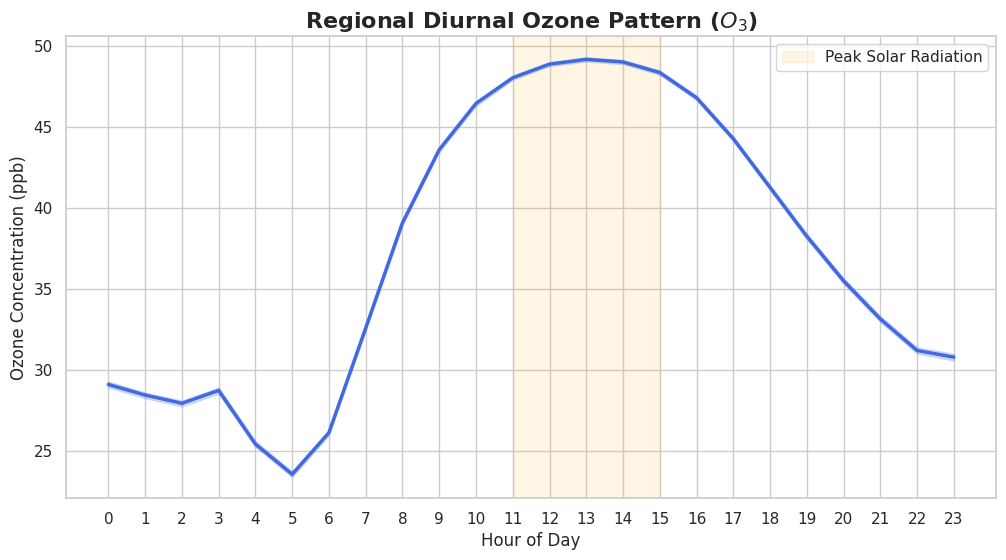

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

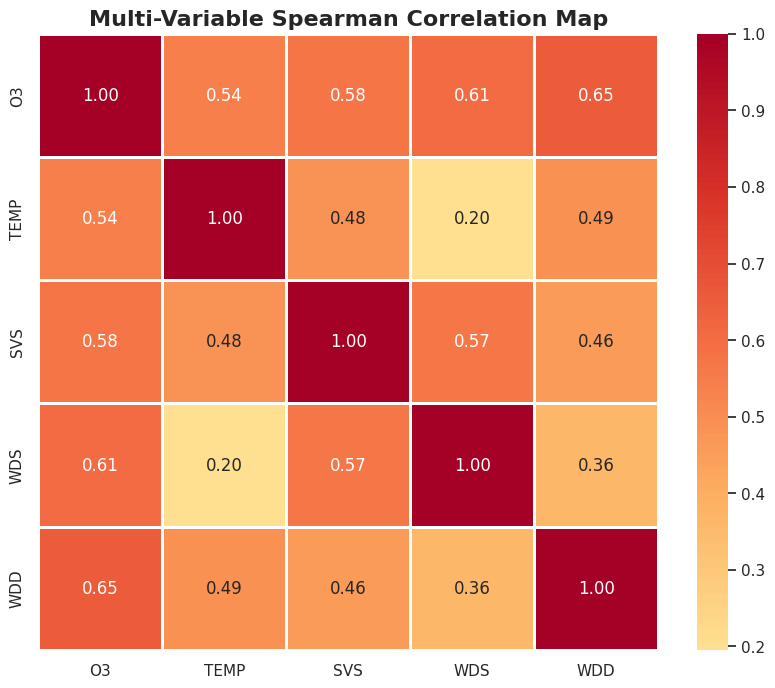

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# ============================================================
# 18. Research Visualizations: Diurnal Patterns & Correlations
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files # Required for automatic download

sns.set_theme(style="whitegrid")

# Plot A: Diurnal Ozone Pattern
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_long, x=df_long['datetime'].dt.hour, y='O3', color='royalblue', linewidth=2.5)
plt.title('Regional Diurnal Ozone Pattern ($O_3$)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Ozone Concentration (ppb)', fontsize=12)
plt.xticks(range(0, 24))
plt.axvspan(11, 15, color='orange', alpha=0.1, label='Peak Solar Radiation')
plt.legend()

# Save and Trigger Download
plot_a_name = 'diurnal_ozone_pattern.png'
plt.savefig(plot_a_name, dpi=300, bbox_inches='tight')
plt.show()
files.download(plot_a_name) # This will trigger the browser download

# Plot B: Multi-Variable Correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, fmt=".2f", linewidths=1)
plt.title('Multi-Variable Spearman Correlation Map', fontsize=16, fontweight='bold')

# Save and Trigger Download
plot_b_name = 'correlation_heatmap.png'
plt.savefig(plot_b_name, dpi=300, bbox_inches='tight')
plt.show()
files.download(plot_b_name) # This will trigger the browser download

In [50]:
# ============================================================
# 19. Statistical Significance Testing (Wilcoxon/Mann-Whitney)
# ============================================================
# Comparing O3 levels between periods specifically during Stable West Winds.
# Addresses the lecturer's requirement for pairwise period comparisons.
from scipy.stats import mannwhitneyu

def run_significance_audit(df, target='O3'):
    periods = ["Before", "Construction", "Operation"]
    results = []

    # Pairwise comparisons
    comparisons = [("Before", "Construction"), ("Before", "Operation"), ("Construction", "Operation")]

    print(f"--- Pairwise Significance Audit (Target: {target} during Stable West Winds) ---")

    for p1, p2 in comparisons:
        data1 = df[df['period'] == p1][target].dropna()
        data2 = df[df['period'] == p2][target].dropna()

        # Perform Mann-Whitney U test
        stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')

        res = {
            "Comparison": f"{p1} vs {p2}",
            "Mean_P1": data1.mean(),
            "Mean_P2": data2.mean(),
            "Diff (%)": ((data2.mean() - data1.mean()) / data1.mean()) * 100,
            "p-value": p_val,
            "Significant": "Yes" if p_val < 0.05 else "No"
        }
        results.append(res)

    return pd.DataFrame(results)

# Execute test specifically for the 'df_west' (Stable Western Winds)
significance_results = run_significance_audit(df_west)
display(significance_results)

--- Pairwise Significance Audit (Target: O3 during Stable West Winds) ---


,Comparison,Mean_P1,Mean_P2,Diff (%),p-value,Significant
0,Before vs Construction,48.713072,48.976804,0.541399,1.076773e-01,No
1,Before vs Operation,48.713072,51.363756,5.441422,4.211669e-117,Yes
2,Construction vs Operation,48.976804,51.363756,4.873637,2.090934e-43,Yes


/tmp/ipykernel_11600/724697726.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_west, x='period', y='O3', order=order, palette="Set2", showfliers=False)


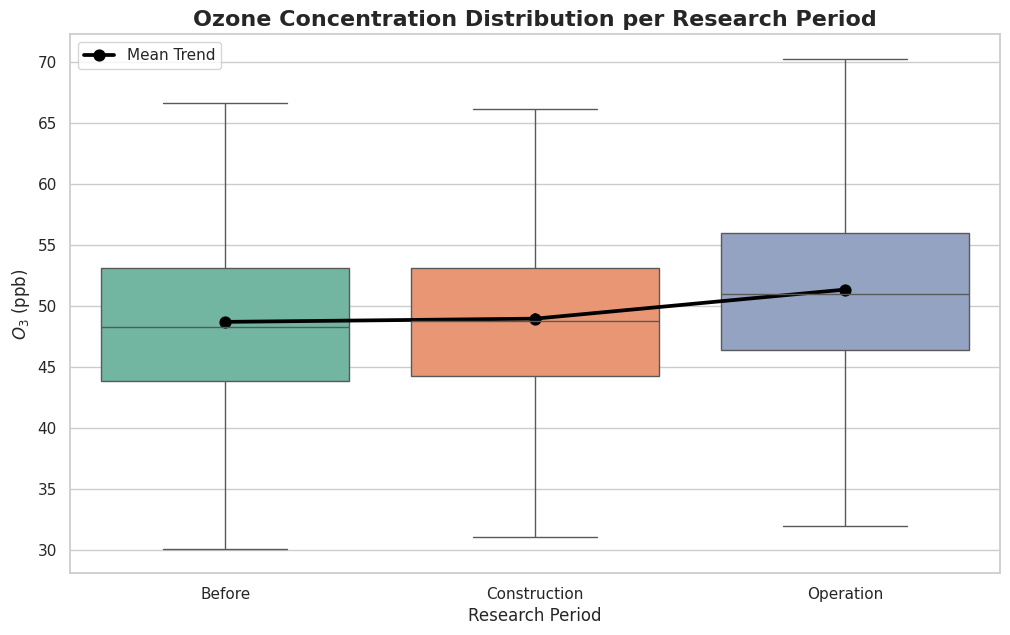

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
# ============================================================
# 20. Ozone Distribution by Period (Stable West Winds)
# ============================================================
plt.figure(figsize=(12, 7))
order = ["Before", "Construction", "Operation"]
sns.boxplot(data=df_west, x='period', y='O3', order=order, palette="Set2", showfliers=False)
sns.pointplot(data=df_west, x='period', y='O3', order=order, color='black', label='Mean Trend')

plt.title('Ozone Concentration Distribution per Research Period', fontsize=16, fontweight='bold')
plt.ylabel('$O_3$ (ppb)', fontsize=12)
plt.xlabel('Research Period', fontsize=12)

# Save and Trigger Download
plot_c_name = 'ozone_period_distribution.png'
plt.savefig(plot_c_name, dpi=300, bbox_inches='tight')
plt.show()
files.download(plot_c_name) # This will trigger the browser download

In [55]:
# ============================================================
# 21. Advanced Temporal Labeling (Fixed)
# ============================================================
# Categorizing data by season and diurnal segments directly on df_west.

# 1. Adding Time and Season features directly to our main research dataframe
df_west["month"] = df_west["datetime"].dt.month
df_west["hour"] = df_west["datetime"].dt.hour
df_west["date"] = df_west["datetime"].dt.date # Required for daily pairing in stats

# 2. Seasonal Classification
df_west["season"] = np.where(df_west["month"].isin([6,7,8]), "summer",
                    np.where(df_west["month"].isin([12,1,2]), "winter", "other"))

# 3. Diurnal Segmentation
def get_time_bucket(h):
    if 6 <= h < 10:   return "morning"
    if 10 <= h < 14:  return "noon"
    if 14 <= h < 18:  return "afternoon"
    if 18 <= h < 22:  return "evening"
    return "night"

df_west["time_bucket"] = df_west["hour"].apply(get_time_bucket)

# Validation check
print("Column 'time_bucket' successfully added to df_west.")
print(f"Sample distribution:\n{df_west['time_bucket'].value_counts()}")

Column 'time_bucket' successfully added to df_west.
Sample distribution:
time_bucket
afternoon    9794
noon         7231
evening      2039
night         934
morning       522
Name: count, dtype: int64


In [56]:
# ============================================================
# 22. Seasonal Significance Audit (July vs. January)
# ============================================================
# Paired Wilcoxon Signed-Rank test to compare O3 levels during
# stable western winds, paired by station and hour to control for bias.
from scipy.stats import wilcoxon

# Filtering for extreme months only (as per research methodology)
df_season = df[df["month"].isin([1, 7])].copy()
df_season["season_label"] = df_season["month"].map({1: "winter", 7: "summer"})

# Aggregate O3 by station, hour, and season to create paired samples
paired_seasonal = (
    df_season.groupby(["station", "hour", "season_label"])["O3"]
    .mean().reset_index()
    .pivot_table(index=["station", "hour"], columns="season_label", values="O3")
    .dropna()
)

# Statistical Execution
stat, p_val = wilcoxon(paired_seasonal["summer"], paired_seasonal["winter"], alternative="two-sided")

print(f"--- Seasonal Significance Results (N={len(paired_seasonal)} pairs) ---")
print(f" - Average Summer O3: {paired_seasonal['summer'].mean():.2f} ppb")
print(f" - Average Winter O3: {paired_seasonal['winter'].mean():.2f} ppb")
print(f" - Wilcoxon p-value: {p_val:.4e}")
print(f" - Significant Change: {'Yes' if p_val < 0.05 else 'No'}")
print(f" - Percentage of hours where Summer > Winter: {(paired_seasonal['summer'] > paired_seasonal['winter']).mean()*100:.1f}%")

--- Seasonal Significance Results (N=59 pairs) ---
 - Average Summer O3: 49.70 ppb
 - Average Winter O3: 42.46 ppb
 - Wilcoxon p-value: 1.0689e-09
 - Significant Change: Yes
 - Percentage of hours where Summer > Winter: 91.5%


In [57]:
# ============================================================
# 23. Diurnal Pairwise Significance Audit
# ============================================================
def run_diurnal_audit(df_input):
    time_order = ["morning", "noon", "afternoon", "evening"]
    audit_results = []

    for i in range(len(time_order) - 1):
        t1, t2 = time_order[i], time_order[i+1]

        # Filtering for the two buckets to compare
        sub = df_input[df_input["time_bucket"].isin([t1, t2])].copy()

        # Aggregate to daily mean per station for pairing
        daily = sub.groupby(["station", "date", "time_bucket"])["O3"].mean().reset_index()
        paired = daily.pivot_table(index=["station", "date"], columns="time_bucket", values="O3").dropna()

        if len(paired) >= 20:
            stat, p = wilcoxon(paired[t2], paired[t1], alternative="two-sided")

            audit_results.append({
                "Comparison": f"{t2} vs {t1}",
                "N_Pairs": len(paired),
                "p_value": p,
                "Significant": "Yes" if p < 0.05 else "No",
                "T2_Greater_T1 (%)": (paired[t2] > paired[t1]).mean() * 100,
                "Median_Diff": paired[t2].median() - paired[t1].median()
            })

    return pd.DataFrame(audit_results)

# Execute on the correctly updated dataframe
diurnal_results = run_diurnal_audit(df_west)
display(diurnal_results)

,Comparison,N_Pairs,p_value,Significant,T2_Greater_T1 (%),Median_Diff
0,noon vs morning,224,1.687040e-01,No,45.535714,0.0000
1,afternoon vs noon,2233,6.617619e-134,Yes,24.675325,-1.7500
2,evening vs afternoon,1050,1.990115e-99,Yes,20.380952,-2.9125


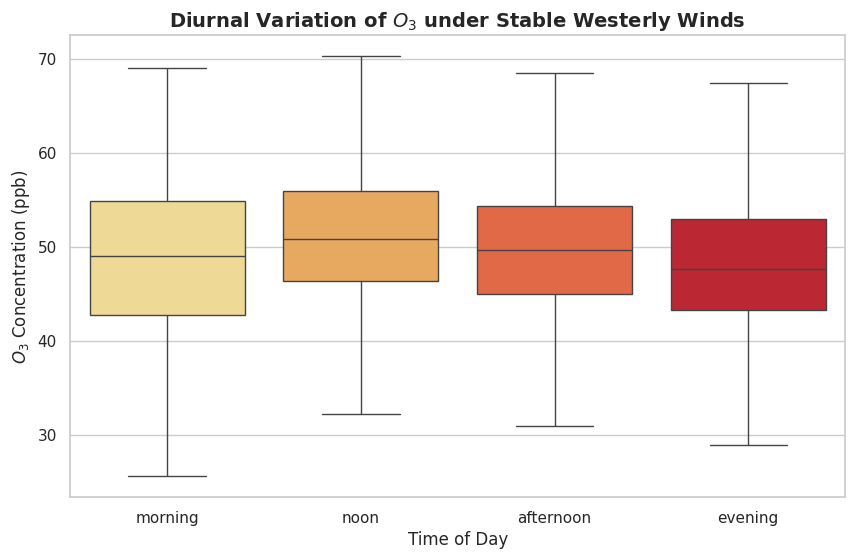

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

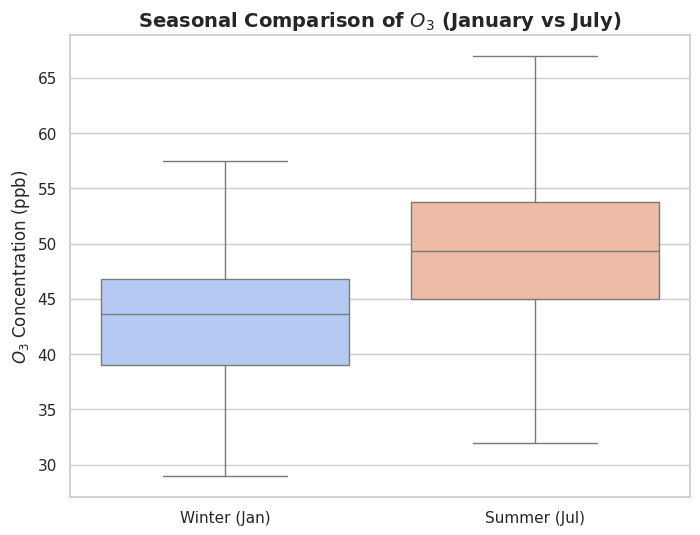

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

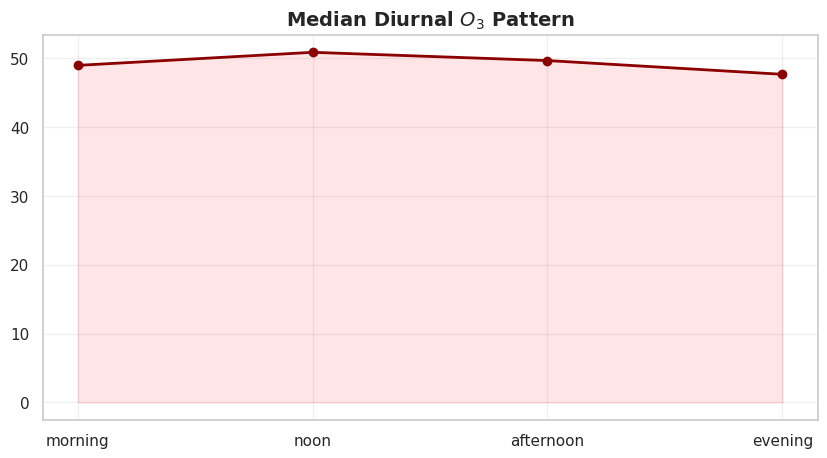

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
# ============================================================
# 24. Research Visualizations: Diurnal & Seasonal Patterns
# ============================================================
# Generating high-resolution visuals for presentation and GitHub.

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure consistent categorical order
time_order = ["morning", "noon", "afternoon", "evening"]
plot_df = df_west.dropna(subset=["O3"]).copy()
plot_df["time_bucket"] = pd.Categorical(plot_df["time_bucket"], categories=time_order, ordered=True)

# --- Plot A: Diurnal Boxplot (Slide 15) ---
plt.figure(figsize=(10, 6))
# Using 'hue' ensures compatibility and professional coloring
sns.boxplot(data=plot_df, x="time_bucket", y="O3", hue="time_bucket",
            palette="YlOrRd", showfliers=False, legend=False)
plt.title("Diurnal Variation of $O_3$ under Stable Westerly Winds", fontsize=14, fontweight='bold')
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("$O_3$ Concentration (ppb)", fontsize=12)
plt.savefig('diurnal_boxplot_o3.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('diurnal_boxplot_o3.png')

# --- Plot B: Seasonal Comparison (Jan vs July) ---
# Filtering for the target months for seasonal contrast
season_df = df_west[df_west["month"].isin([1, 7])].copy()
season_df["season_label"] = season_df["month"].map({1: "Winter (Jan)", 7: "Summer (Jul)"})

plt.figure(figsize=(8, 6))
sns.boxplot(data=season_df, x="season_label", y="O3", hue="season_label",
            palette="coolwarm", showfliers=False, legend=False)
plt.title("Seasonal Comparison of $O_3$ (January vs July)", fontsize=14, fontweight='bold')
plt.ylabel("$O_3$ Concentration (ppb)", fontsize=12)
plt.xlabel("")
plt.savefig('seasonal_comparison_o3.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('seasonal_comparison_o3.png')

# --- Plot C: Median Diurnal Trend Line ---
median_time = plot_df.groupby("time_bucket", observed=True)["O3"].median().reindex(time_order)
plt.figure(figsize=(10, 5))
plt.plot(median_time.index, median_time.values, marker="o", linestyle="-", color="darkred", linewidth=2)
plt.fill_between(median_time.index, median_time.values, color="red", alpha=0.1)
plt.title("Median Diurnal $O_3$ Pattern", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('median_diurnal_trend.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('median_diurnal_trend.png')

Sample distribution per wind strength category:
wind_strength
Moderate    11564
Weak         8093
Strong        863
Name: count, dtype: int64

--- Wind Strength Significance Audit ---
 - Median O3 (Weak Wind): 48.70 ppb
 - Median O3 (Strong Wind): 50.15 ppb
 - p-value (Mann-Whitney): 2.8622e-07
 - Significant: Yes


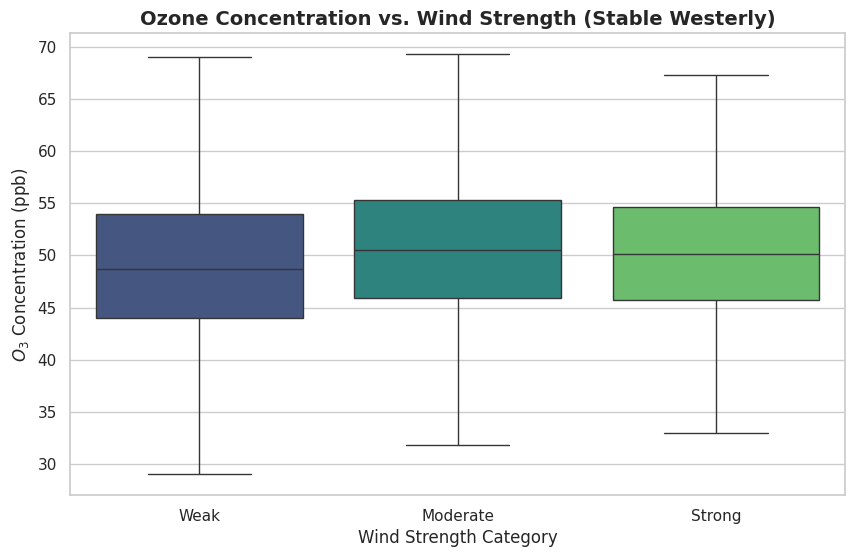

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# ============================================================
# 25. Wind Strength Stratification & Impact Analysis
# ============================================================
# Categorizing wind intensity to analyze its role in pollutant transport (Slide 16).
# Logic: Comparing O3 levels under different transport velocities.

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# 1. Classification
def categorize_wind_strength(wds):
    if wds <= 3: return "Weak"
    if wds <= 6: return "Moderate"
    return "Strong"

df_west["wind_strength"] = df_west["WDS"].apply(categorize_wind_strength)
# Setting category order for plots
wind_order = ["Weak", "Moderate", "Strong"]
df_west["wind_strength"] = pd.Categorical(df_west["wind_strength"], categories=wind_order, ordered=True)

# 2. Descriptive Statistics
print("Sample distribution per wind strength category:")
print(df_west["wind_strength"].value_counts())

# 3. Statistical Significance Test (Weak vs Strong)
weak_o3 = df_west[df_west["wind_strength"] == "Weak"]["O3"].dropna()
strong_o3 = df_west[df_west["wind_strength"] == "Strong"]["O3"].dropna()

if len(weak_o3) > 0 and len(strong_o3) > 0:
    stat, p_val = mannwhitneyu(weak_o3, strong_o3, alternative='two-sided')
    print(f"\n--- Wind Strength Significance Audit ---")
    print(f" - Median O3 (Weak Wind): {weak_o3.median():.2f} ppb")
    print(f" - Median O3 (Strong Wind): {strong_o3.median():.2f} ppb")
    print(f" - p-value (Mann-Whitney): {p_val:.4e}")
    print(f" - Significant: {'Yes' if p_val < 0.05 else 'No'}")

# 4. Visualization (Replicating Slide 16 logic)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_west, x="wind_strength", y="O3", hue="wind_strength",
            palette="viridis", showfliers=False, legend=False)
plt.title("Ozone Concentration vs. Wind Strength (Stable Westerly)", fontsize=14, fontweight='bold')
plt.xlabel("Wind Strength Category", fontsize=12)
plt.ylabel("$O_3$ Concentration (ppb)", fontsize=12)

# Save and Download
plt.savefig('wind_strength_o3_impact.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('wind_strength_o3_impact.png')

--- General Wind Strength Audit (N=226 pairs) ---
 - Median O3 (Weak Wind): 47.49 ppb
 - Median O3 (Strong Wind): 50.70 ppb
 - p-value: 1.1397e-22
 - Significant: Yes
 - Share of days where Weak > Strong: 18.1%


/tmp/ipykernel_11600/154342793.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=paired_wind.melt(var_name="Wind Strength", value_name="O3"),


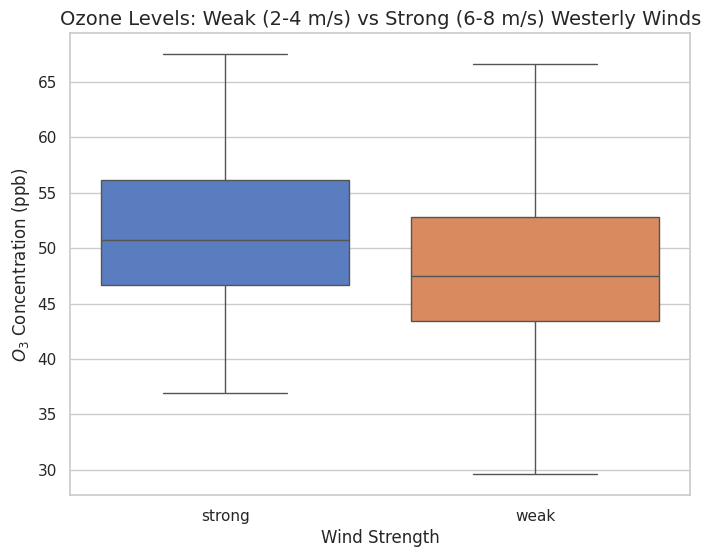

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
# ============================================================
# 26. Wind Strength Significance Audit (General)
# ============================================================
# Compares O3 levels between 'Weak' (2-4 m/s) and 'Strong' (6-8 m/s) winds.
# Paired by station and date to isolate the effect of wind transport (Slide 16).

from scipy.stats import wilcoxon

# 1. Classification & Data Preparation
df_ws = df_west.copy()
df_ws["wind_strength"] = pd.NA
df_ws.loc[(df_ws["WDS"] >= 2) & (df_ws["WDS"] <= 4), "wind_strength"] = "weak"
df_ws.loc[(df_ws["WDS"] >= 6) & (df_ws["WDS"] <= 8), "wind_strength"] = "strong"

# Aggregate to daily mean per station/strength
daily_o3 = df_ws.dropna(subset=["wind_strength"]).groupby(["station", "date", "wind_strength"])["O3"].mean().reset_index()
paired_wind = daily_o3.pivot_table(index=["station", "date"], columns="wind_strength", values="O3").dropna()

# 2. Statistical Execution
if len(paired_wind) >= 10:
    stat, p_val = wilcoxon(paired_wind["weak"], paired_wind["strong"], alternative="two-sided")

    print(f"--- General Wind Strength Audit (N={len(paired_wind)} pairs) ---")
    print(f" - Median O3 (Weak Wind): {paired_wind['weak'].median():.2f} ppb")
    print(f" - Median O3 (Strong Wind): {paired_wind['strong'].median():.2f} ppb")
    print(f" - p-value: {p_val:.4e}")
    print(f" - Significant: {'Yes' if p_val < 0.05 else 'No'}")
    print(f" - Share of days where Weak > Strong: {(paired_wind['weak'] > paired_wind['strong']).mean()*100:.1f}%")

# 3. Visualization
plt.figure(figsize=(8, 6))
sns.boxplot(data=paired_wind.melt(var_name="Wind Strength", value_name="O3"),
            x="Wind Strength", y="O3", palette="muted", showfliers=False)
plt.title("Ozone Levels: Weak (2-4 m/s) vs Strong (6-8 m/s) Westerly Winds", fontsize=14)
plt.ylabel("$O_3$ Concentration (ppb)")
plt.savefig('wind_strength_paired_comparison.png', dpi=300)
plt.show()
files.download('wind_strength_paired_comparison.png')

--- July Wind Transport Audit (N=29 pairs) ---
 - Median O3 (Strong Wind): 53.25 ppb
 - Median O3 (Weak Wind): 51.40 ppb
 - p-value (Strong > Weak): 1.0639e-02
 - Significant: Yes
 - Share of days where Strong > Weak: 69.0%


/tmp/ipykernel_11600/1934389383.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=paired_july.melt(var_name="Wind Strength", value_name="O3"),


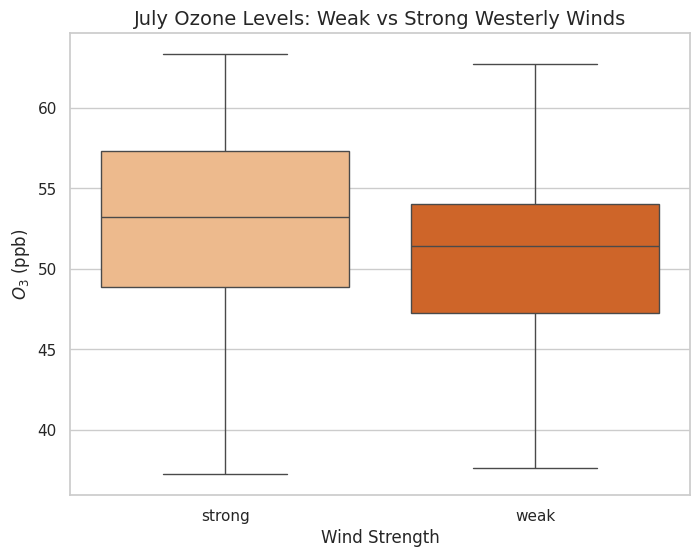

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
# ============================================================
# 27. Summer-Specific Wind Impact (July Audit)
# ============================================================
# Focused analysis on July to isolate transport effects under maximum
# photochemical potential (Slide 15-16).

# 1. Filtering for July and reapplying strength logic
df_july = df_west[df_west["month"] == 7].copy()
df_july["wind_strength"] = pd.NA
df_july.loc[(df_july["WDS"] >= 2) & (df_july["WDS"] <= 4), "wind_strength"] = "weak"
df_july.loc[(df_july["WDS"] >= 6) & (df_july["WDS"] <= 8), "wind_strength"] = "strong"

# Aggregate and pair
daily_o3_july = df_july.dropna(subset=["wind_strength"]).groupby(["station", "date", "wind_strength"])["O3"].mean().reset_index()
paired_july = daily_o3_july.pivot_table(index=["station", "date"], columns="wind_strength", values="O3").dropna()

# 2. Statistical Execution (One-sided: Testing if Strong > Weak as expected in transport theory)
if len(paired_july) >= 5:
    stat_j, p_j = wilcoxon(paired_july["strong"], paired_july["weak"], alternative="greater")

    print(f"--- July Wind Transport Audit (N={len(paired_july)} pairs) ---")
    print(f" - Median O3 (Strong Wind): {paired_july['strong'].median():.2f} ppb")
    print(f" - Median O3 (Weak Wind): {paired_july['weak'].median():.2f} ppb")
    print(f" - p-value (Strong > Weak): {p_j:.4e}")
    print(f" - Significant: {'Yes' if p_j < 0.05 else 'No'}")
    print(f" - Share of days where Strong > Weak: {(paired_july['strong'] > paired_july['weak']).mean()*100:.1f}%")

# 3. Seasonal Visualization
plt.figure(figsize=(8, 6))
sns.boxplot(data=paired_july.melt(var_name="Wind Strength", value_name="O3"),
            x="Wind Strength", y="O3", palette="Oranges", showfliers=False)
plt.title("July Ozone Levels: Weak vs Strong Westerly Winds", fontsize=14)
plt.ylabel("$O_3$ (ppb)")
plt.savefig('july_wind_impact.png', dpi=300)
plt.show()
files.download('july_wind_impact.png')

In [62]:
# ============================================================
# 28. Rig Impact Preparation: Dynamic Station-Specific Filtering
# ============================================================
# Logic:
# 1. Periods: Pre-Installation (2018-19), Running-In (2020), Operation (2021+).
# 2. Wind Sector: Broad Westerly definition (202.5°-337.5°) per updated guidelines.
# 3. Dynamic Thresholds: 'Moderate' wind speed defined as 25th-75th percentile
#    separately for each station to account for local micro-climates.

def assign_rig_period(dt):
    if dt.year in [2018, 2019]: return "1_Pre_Installation"
    if dt.year == 2020:         return "2_Running_In"
    if dt.year >= 2021:         return "3_Operation"
    return "Other"

WEST_MIN, WEST_MAX = 202.5, 337.5
df_analysed = []
stations = sorted(set(str(c[0]).strip() for c in hourly_imputed.columns))

for st in stations:
    # 1. Extract station data
    st_data = hourly_imputed.xs(st, level=0, axis=1)
    if 'WDS' not in st_data.columns or 'WDD' not in st_data.columns or 'O3' not in st_data.columns:
        continue

    # 2. Calculate dynamic thresholds (25th - 75th percentile)
    wds_vals = pd.to_numeric(st_data['WDS'].iloc[:,0] if isinstance(st_data['WDS'], pd.DataFrame) else st_data['WDS'], errors='coerce').dropna()
    if len(wds_vals) < 100: continue
    low_wds, high_wds = np.percentile(wds_vals, 25), np.percentile(wds_vals, 75)

    # 3. Build filtered dataframe for station
    st_df = pd.DataFrame(index=st_data.index)
    st_df['O3'] = pd.to_numeric(st_data['O3'].iloc[:,0] if isinstance(st_data['O3'], pd.DataFrame) else st_data['O3'], errors='coerce')
    st_df['WDS'] = pd.to_numeric(st_data['WDS'].iloc[:,0] if isinstance(st_data['WDS'], pd.DataFrame) else st_data['WDS'], errors='coerce')
    st_df['WDD'] = pd.to_numeric(st_data['WDD'].iloc[:,0] if isinstance(st_data['WDD'], pd.DataFrame) else st_data['WDD'], errors='coerce')
    st_df['SVS'] = pd.to_numeric(st_data['SVS'].iloc[:,0], errors='coerce') if 'SVS' in st_data.columns else 0

    st_df['Station'] = st
    st_df['Period'] = st_df.index.map(assign_rig_period)
    st_df['Month'] = st_df.index.month
    st_df['Hour'] = st_df.index.hour

    # 4. Filtering: Western wind + Moderate speed
    mask_west = (st_df['WDD'] >= WEST_MIN) & (st_df['WDD'] <= WEST_MAX)
    mask_speed = (st_df['WDS'] >= low_wds) & (st_df['WDS'] <= high_wds)
    st_df['Is_Westerly_Moderate'] = mask_west & mask_speed

    df_analysed.append(st_df)

full_analysis_df = pd.concat(df_analysed)
df_target = full_analysis_df[(full_analysis_df['Is_Westerly_Moderate'] == True) & (full_analysis_df['Period'] != "Other")].copy()

print(f"Preparation Complete. Targeted rows for Rig Impact Study: {len(df_target)}")

Preparation Complete. Targeted rows for Rig Impact Study: 60936


In [78]:
# ============================================================
# 29. Pairwise Significance & Station Declaration
# ============================================================
from scipy.stats import mannwhitneyu
import itertools

# 1. הצהרת התחנות המשתתפות במחקר (דרישת המנחה)
active_stations = df_target['Station'].unique()
print(f"--- Research Audit ---")
print(f"Stations participating in analysis: {', '.join(active_stations)}")
print(f"Target Variable: O3 (Ozone Concentration)")
print("-" * 30)

def pairwise_impact_analysis(df):
    results = []
    periods = ["1_Pre_Installation", "2_Running_In", "3_Operation"]
    # יצירת כל הזוגות האפשריים להשוואה (דרישת המנחה)
    comparisons = list(itertools.combinations(periods, 2))

    for st in active_stations:
        # חישוב סטיית תקן של ה-O3 בתחנה (דרישת המנחה)
        st_std = df[df['Station'] == st]['O3'].std()

        for p1, p2 in comparisons:
            data1 = df[(df['Station'] == st) & (df['Period'] == p1)]['O3'].dropna()
            data2 = df[(df['Station'] == st) & (df['Period'] == p2)]['O3'].dropna()

            if len(data1) > 30 and len(data2) > 30:
                # מבחן Mann-Whitney להשוואת התפלגויות (דו-צדדי)
                stat, p_val = mannwhitneyu(data2, data1, alternative='two-sided')

                mean_1 = data1.mean()
                mean_2 = data2.mean()
                pct_change = ((mean_2 - mean_1) / mean_1) * 100

                results.append({
                    'Station': st,
                    'Comparison': f"{p2} vs {p1}",
                    'P_Value': round(p_val, 4),
                    'Significant': 'Yes' if p_val < 0.05 else 'No',
                    'Mean_1': round(mean_1, 2),
                    'Mean_2': round(mean_2, 2),
                    'Change_Pct': f"{round(pct_change, 1)}%",
                    'Change_Val': pct_change,
                    'Target_STD': round(st_std, 2)
                })
    return pd.DataFrame(results)

# הרצת הניתוח
pairwise_results = pairwise_impact_analysis(df_target)

# יצירת טבלה ייעודית לגרפים (השוואת קצה: Operation vs Pre)
# זה מבטיח שקוביה 30 תמשיך לעבוד עם הנתונים הנכונים
final_report_df = pairwise_results[pairwise_results['Comparison'] == "3_Operation vs 1_Pre_Installation"].copy()
final_report_df = final_report_df.rename(columns={'Mean_1': 'Pre_Mean_ppb', 'Mean_2': 'Post_Mean_ppb', 'P_Value': 'P_Value'})

print("Pairwise Statistical Summary:")
display(pairwise_results.head(12))

# ייצוא לאקסל של כל ההשוואות (דרישת המנחה)
report_path = "O3_Full_Pairwise_Statistical_Report.xlsx"
pairwise_results.to_excel(report_path, index=False)
files.download(report_path)

--- Research Audit ---
Stations participating in analysis: G.ADA, HAMAPIL, K.MAHARAL, KARON IGUD
Target Variable: O3 (Ozone Concentration)
------------------------------
Pairwise Statistical Summary:


,Station,Comparison,P_Value,Significant,Mean_1,Mean_2,Change_Pct,Change_Val,Target_STD
0,G.ADA,2_Running_In vs 1_Pre_Installation,0.0,Yes,46.33,40.01,-13.7%,-13.652311,9.89
1,G.ADA,3_Operation vs 1_Pre_Installation,0.0,Yes,46.33,45.05,-2.8%,-2.762960,9.89
2,G.ADA,3_Operation vs 2_Running_In,0.0,Yes,40.01,45.05,12.6%,12.611051,9.89
3,HAMAPIL,2_Running_In vs 1_Pre_Installation,0.0,Yes,40.72,43.36,6.5%,6.486420,11.59
4,HAMAPIL,3_Operation vs 1_Pre_Installation,0.0,Yes,40.72,45.86,12.6%,12.630380,11.59
5,HAMAPIL,3_Operation vs 2_Running_In,0.0,Yes,43.36,45.86,5.8%,5.769712,11.59
6,K.MAHARAL,2_Running_In vs 1_Pre_Installation,0.0,Yes,49.24,50.58,2.7%,2.723307,9.94
7,K.MAHARAL,3_Operation vs 1_Pre_Installation,0.0,Yes,49.24,52.58,6.8%,6.790844,9.94
8,K.MAHARAL,3_Operation vs 2_Running_In,0.0,Yes,50.58,52.58,4.0%,3.959702,9.94
9,KARON IGUD,2_Running_In vs 1_Pre_Installation,0.0,Yes,39.43,41.32,4.8%,4.803694,12.70


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

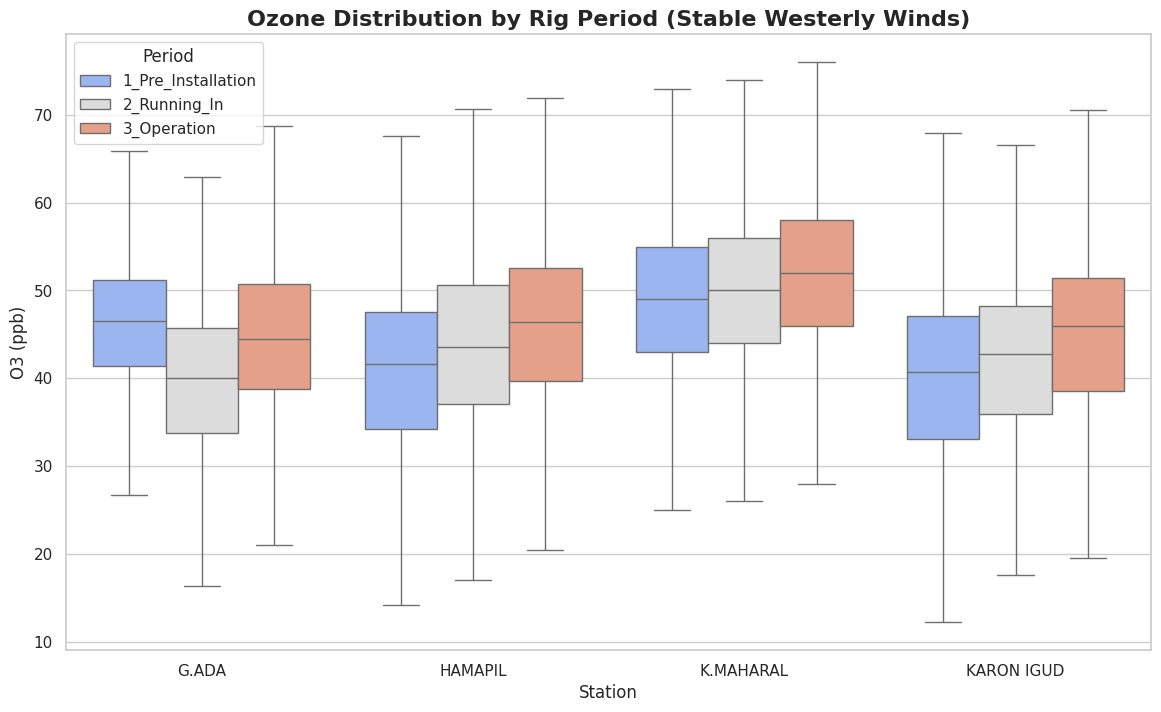

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_11600/1516362052.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_data, x='Station', y='Change_Val', palette=colors)


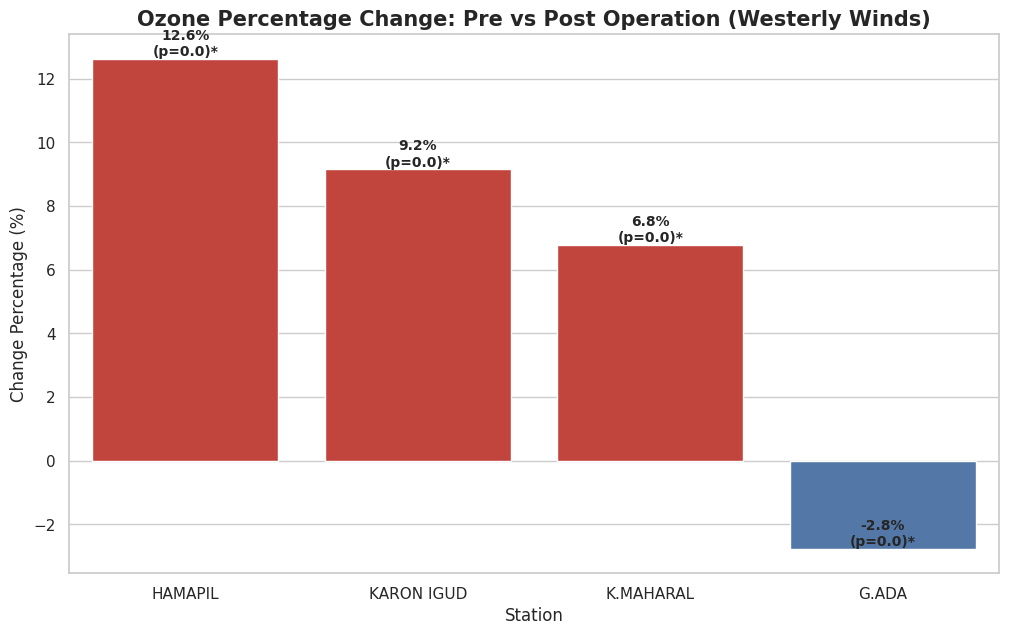

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

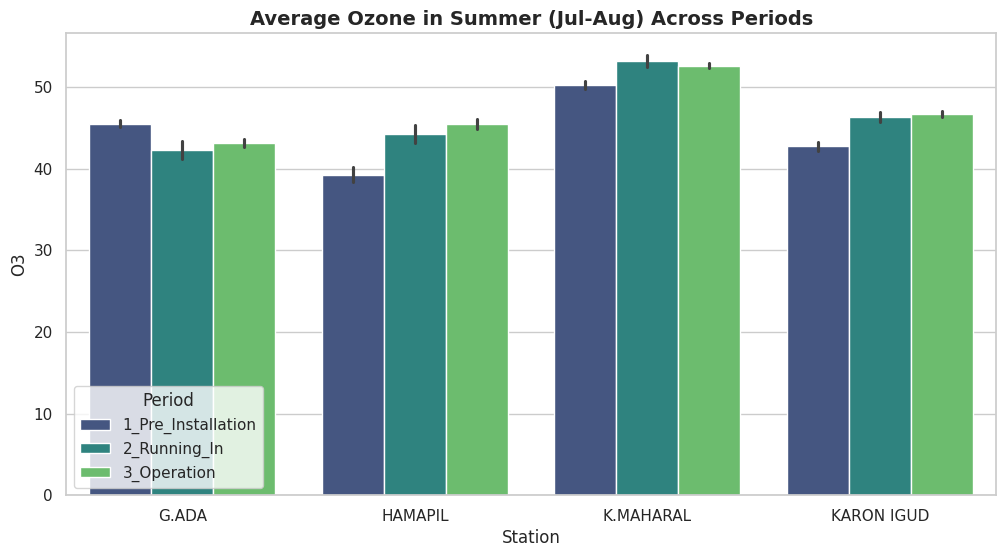

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

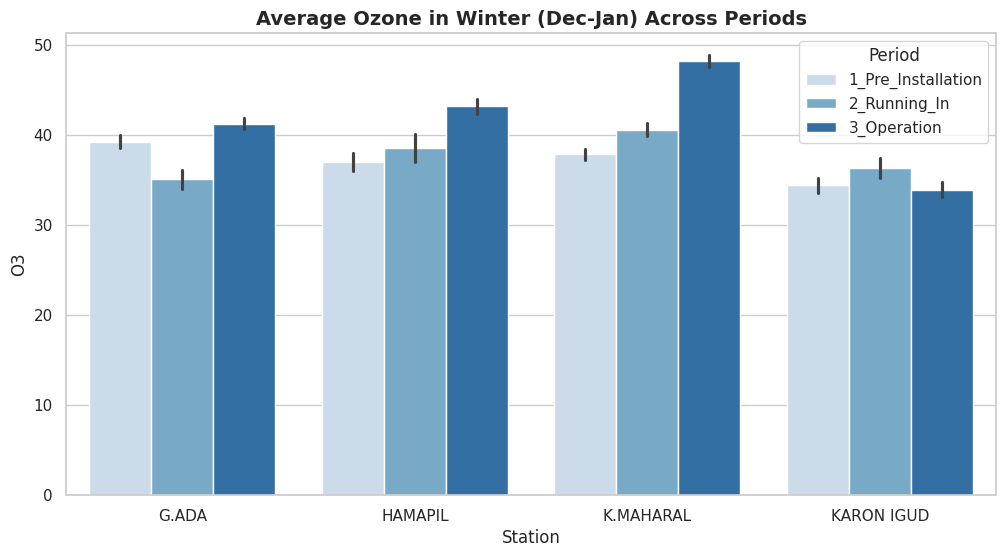

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
# ============================================================
# 30. Rig Impact Visualizations (Slide 18 & 20)
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
df_plot = df_target.reset_index()

# 1. Regional Boxplot Comparison
plt.figure(figsize=(14, 8))
sns.boxplot(data=df_plot, x='Station', y='O3', hue='Period', palette='coolwarm', showfliers=False)
plt.title('Ozone Distribution by Rig Period (Stable Westerly Winds)', fontsize=16, fontweight='bold')
plt.ylabel('O3 (ppb)')
plt.savefig('rig_impact_boxplot.png', dpi=300)
plt.show()
files.download('rig_impact_boxplot.png')

# 2. Percentage Change Bar Chart (The Summary Chart)
plt.figure(figsize=(12, 7))
plot_data = final_report_df.sort_values('Change_Val', ascending=False)
colors = ['#d73027' if (r['Significant'] == 'Yes' and r['Change_Val'] > 0) else '#4575b4' for _, r in plot_data.iterrows()]

ax = sns.barplot(data=plot_data, x='Station', y='Change_Val', palette=colors)
plt.title('Ozone Percentage Change: Pre vs Post Operation (Westerly Winds)', fontsize=15, fontweight='bold')
plt.ylabel('Change Percentage (%)')

# Add p-values and asterisks
for i, p in enumerate(ax.patches):
    row = plot_data.iloc[i]
    label = f"{row['Change_Pct']}\n(p={row['P_Value']})"
    if row['Significant'] == 'Yes': label += "*"
    ax.annotate(label, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.savefig('final_impact_summary_bar.png', dpi=300)
plt.show()
files.download('final_impact_summary_bar.png')

# 3. Seasonal Summer/Winter Bars
for season_name, months in [('Summer (Jul-Aug)', [7, 8]), ('Winter (Dec-Jan)', [12, 1])]:
    seas_df = df_plot[df_plot['Month'].isin(months)]
    plt.figure(figsize=(12, 6))
    sns.barplot(data=seas_df, x='Station', y='O3', hue='Period', palette='viridis' if 'Summer' in season_name else 'Blues')
    plt.title(f'Average Ozone in {season_name} Across Periods', fontsize=14, fontweight='bold')
    plt.savefig(f'{season_name.split()[0].lower()}_comparison.png', dpi=300)
    plt.show()
    files.download(f'{season_name.split()[0].lower()}_comparison.png')

תחילת בניית מודל חיזוי

In [80]:
# ============================================================
# 31. ML Data Preparation
# ============================================================
# Mapping spatial features and preparing the feature matrix for modeling.

# 1. Spatial distance mapping from the gas rig (km)
distance_map = {
    'MAAYAN ZVI': 10, 'K.MAHARAL': 14, 'ELYAKIM': 18,
    'G.ADA': 21, 'KARON IGUD': 22, 'P.HANA': 23, 'HAMAPIL': 26
}

# 2. Preparing the ML dataset from df_west
df_ml = df_west.copy()
df_ml['Distance_km'] = df_ml['station'].str.strip().str.upper().map(distance_map)

# 3. Operational Status (Binary indicator for post-2021 activity)
df_ml['Is_Operational'] = (df_ml['datetime'].dt.year >= 2021).astype(int)

# 4. Feature Selection
features = ['Distance_km', 'WDD', 'WDS', 'TEMP', 'SVS', 'month', 'hour', 'Is_Operational']
target = 'O3'

# Clean missing values specifically for ML features
df_ml = df_ml.dropna(subset=features + [target])

print(f"ML Dataset Ready. Training samples: {len(df_ml)}")
display(df_ml[features + [target]].head())

ML Dataset Ready. Training samples: 5149


,Distance_km,WDD,WDS,TEMP,SVS,month,hour,Is_Operational,O3
234781,26,284.0,2.5,17.5,490.0,1,13,0,41.7
234784,26,263.0,2.7,15.9,45.0,1,16,0,41.0
234805,26,285.0,5.4,16.7,446.0,1,13,0,46.6
234997,26,284.0,4.8,16.5,461.0,1,13,0,49.3
234998,26,289.0,4.5,16.3,267.0,1,14,0,48.9


In [81]:
# ============================================================
# 32. Model Training: Linear Regression vs. Random Forest
# ============================================================

# 1. Split into Features (X) and Target (y)
X = df_ml[features]
y = df_ml[target]

# 2. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Baseline Model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 4. Advanced Model: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 5. Comparative Performance Summary
results_summary = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (ppb)'],
    'Linear Regression': [r2_score(y_test, y_pred_lr), np.sqrt(mean_squared_error(y_test, y_pred_lr))],
    'Random Forest': [r2_score(y_test, y_pred_rf), np.sqrt(mean_squared_error(y_test, y_pred_rf))]
})

print("=== Model Performance Comparison ===")
display(results_summary)

=== Model Performance Comparison ===


,Metric,Linear Regression,Random Forest
0,R2 Score,0.174796,0.343976
1,RMSE (ppb),6.905286,6.156883


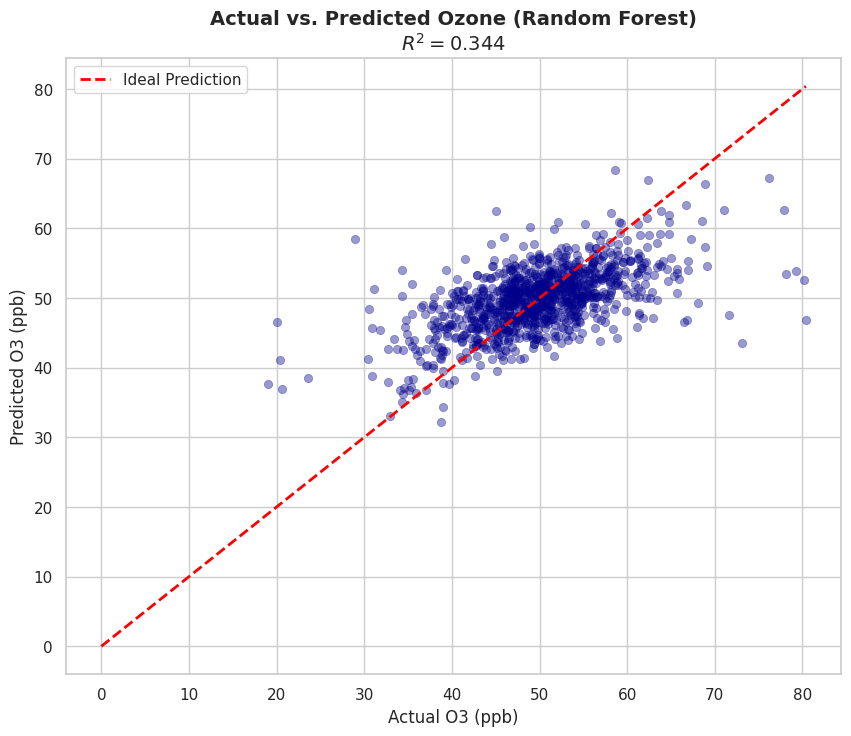

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

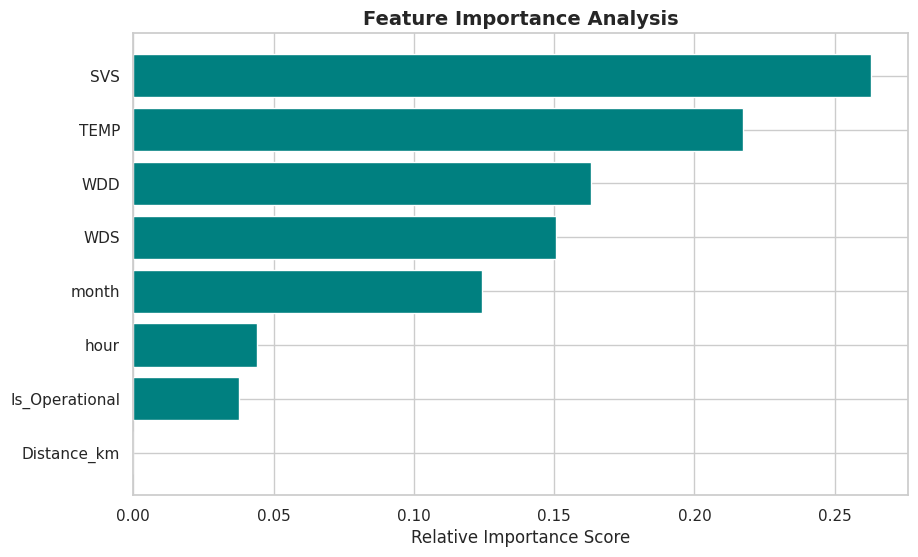

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

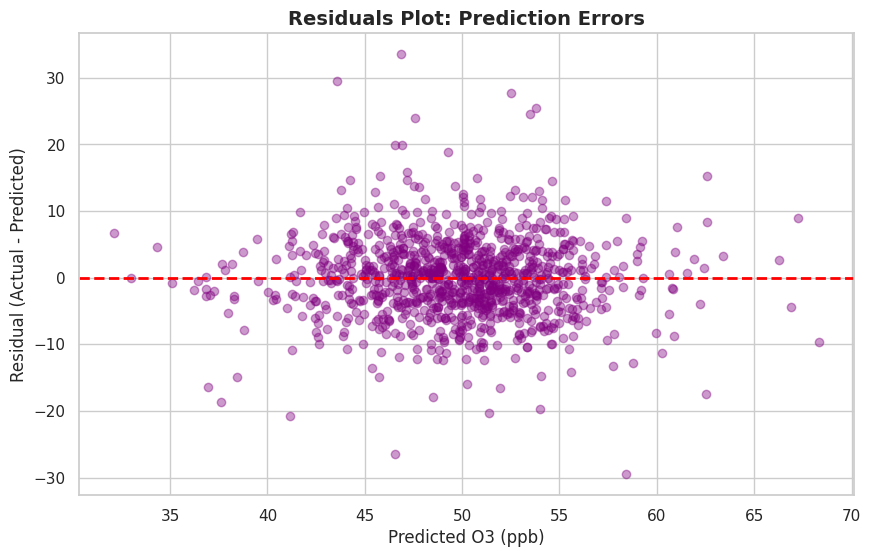

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
# ============================================================
# 33. Model Evaluation Visualizations & Export
# ============================================================

# Plot A: Actual vs. Predicted (Random Forest)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.4, color='darkblue', edgecolor=None)
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Ideal Prediction')
plt.title(f'Actual vs. Predicted Ozone (Random Forest)\n$R^2 = {r2_score(y_test, y_pred_rf):.3f}$', fontsize=14, fontweight='bold')
plt.xlabel('Actual O3 (ppb)')
plt.ylabel('Predicted O3 (ppb)')
plt.legend()
plt.savefig('rf_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('rf_actual_vs_predicted.png')

# Plot B: Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('feature_importance.png')

# Plot C: Residuals Plot (Error Analysis)
residuals = y_test - y_pred_rf
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Residuals Plot: Prediction Errors', fontsize=14, fontweight='bold')
plt.xlabel('Predicted O3 (ppb)')
plt.ylabel('Residual (Actual - Predicted)')
plt.savefig('residuals_plot.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('residuals_plot.png')

In [83]:
# ============================================================
# 34. Model Robustness & Hyperparameter Tuning
# ============================================================

# 1. 5-Fold Cross-Validation
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"Cross-Validation R2 Score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# 2. Final Summary Export
results_summary.to_excel('ml_performance_summary.xlsx', index=False)
files.download('ml_performance_summary.xlsx')

# 3. GridSearchCV for Optimization (Optional but high value)
# Adjust param_grid if running time is an issue
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Optimized R2 Score: {grid_search.best_score_:.3f}")

Cross-Validation R2 Score: 0.113 (+/- 0.123)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Best Parameters Found: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Optimized R2 Score: 0.328


=== Model Stability Check (Cross-Validation) ===
Mean R^2: 0.113 (+/- 0.123)
------------------------------


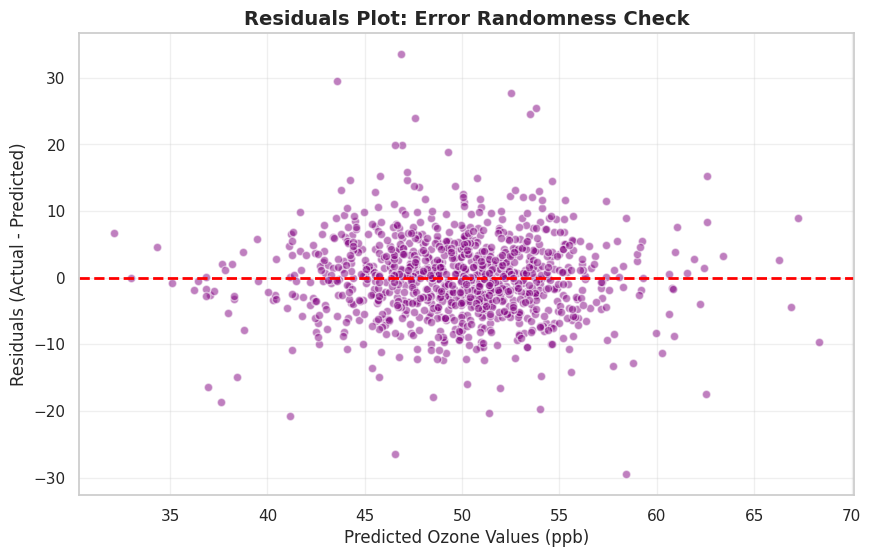

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:
# ============================================================
# 35. Advanced Evaluation: Cross-Validation & Residuals
# ============================================================
# Goal: Prove the model is stable and the errors are random.

# 1. 5-Fold Cross-Validation (Checking stability)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("=== Model Stability Check (Cross-Validation) ===")
print(f"Mean R^2: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
print("-" * 30)

# 2. Residuals Plot (Is the error random?)
residuals = y_test - y_pred_rf
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.5, color='purple', edgecolor='white')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.title('Residuals Plot: Error Randomness Check', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Ozone Values (ppb)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, alpha=0.3)

# Save and Download
res_filename = 'residuals_plot.png'
plt.savefig(res_filename, dpi=300, bbox_inches='tight')
plt.show()
files.download(res_filename)

In [85]:
# ============================================================
# 36. Final Performance Summary Table
# ============================================================

results_summary = pd.DataFrame({
    'Metric': ['R2 Score (Test Set)', 'Mean R2 (Cross-Val)', 'RMSE (ppb)'],
    'Linear Regression': [r2_score(y_test, y_pred_lr), "N/A", np.sqrt(mean_squared_error(y_test, y_pred_lr))],
    'Random Forest': [r2_score(y_test, y_pred_rf), cv_scores.mean(), np.sqrt(mean_squared_error(y_test, y_pred_rf))]
})

print("\n=== Final Performance Table for Report ===")
display(results_summary)

# Export to Excel
table_filename = 'ml_performance_summary.xlsx'
results_summary.to_excel(table_filename, index=False)
files.download(table_filename)
print(f"Table saved and downloaded: {table_filename}")


=== Final Performance Table for Report ===


,Metric,Linear Regression,Random Forest
0,R2 Score (Test Set),0.174796,0.343976
1,Mean R2 (Cross-Val),N/A,0.113242
2,RMSE (ppb),6.905286,6.156883


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Table saved and downloaded: ml_performance_summary.xlsx


In [86]:
# ============================================================
# 37. Hyperparameter Optimization (GridSearchCV)
# ============================================================
# Optimization may take 1-2 minutes.

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 20],
    'min_samples_split': [2, 5]
}

print("Running GridSearchCV for optimization...")
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Optimized R^2 Score: {grid_search.best_score_:.3f}")

# Final Final R2 on Test Set with Best Model
final_r2 = r2_score(y_test, best_rf.predict(X_test))
print(f"Final Test R^2 with Optimized Model: {final_r2:.3f}")

Running GridSearchCV for optimization...
Best Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Optimized R^2 Score: 0.328
Final Test R^2 with Optimized Model: 0.357


In [88]:
# ============================================================
# 38. Model Training: Optimized RF, XGBoost, and Neural Network
# ============================================================
import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# 1. הצהרת התחנות המשתתפות במודל (דרישת מנחה)
model_stations = df_ml['station'].unique()
print(f"Stations used for model training: {', '.join(model_stations)}")

# 2. נרמול נתונים עבור רשת הנוירונים (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. אימון מודל יער רנדומלי (Random Forest) עם הפרמטרים מה-Grid Search
# Optimal parameters: max_depth=15, min_samples_split=5, n_estimators=200
rf_optimized = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)
rf_optimized.fit(X_train, y_train)

# 4. אימון מודל XGBoost
xgb_mod = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_mod.fit(X_train, y_train)

# 5. אימון מודל רשת נוירונים (Neural Network Architecture)
# 2 Hidden Layers: 64 and 32 neurons per supervisor requirement
nn_mod = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)
nn_mod.fit(X_train_scaled, y_train)

print("Model training complete.")

Stations used for model training: HAMAPIL
Model training complete.


--- Linear Regression Feature Contribution (Theta) ---


,Feature,Theta (Coefficient)
7,Is_Operational,2.311142
2,WDS,0.246599
3,TEMP,0.232592
4,SVS,0.004654
0,Distance_km,0.000000
6,hour,-0.069945
1,WDD,-0.105912
5,month,-0.757178



Target Variable (O3) Statistics: Mean=49.61, STD=7.50


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,RMSE_to_STD_Ratio
0,Linear Regression,0.182,0.175,6.76,6.91,0.920
1,Random Forest,0.800,0.357,3.35,6.09,0.812
2,Neural Network,0.439,0.323,5.60,6.25,0.834
3,XGBoost,0.566,0.361,4.93,6.07,0.810


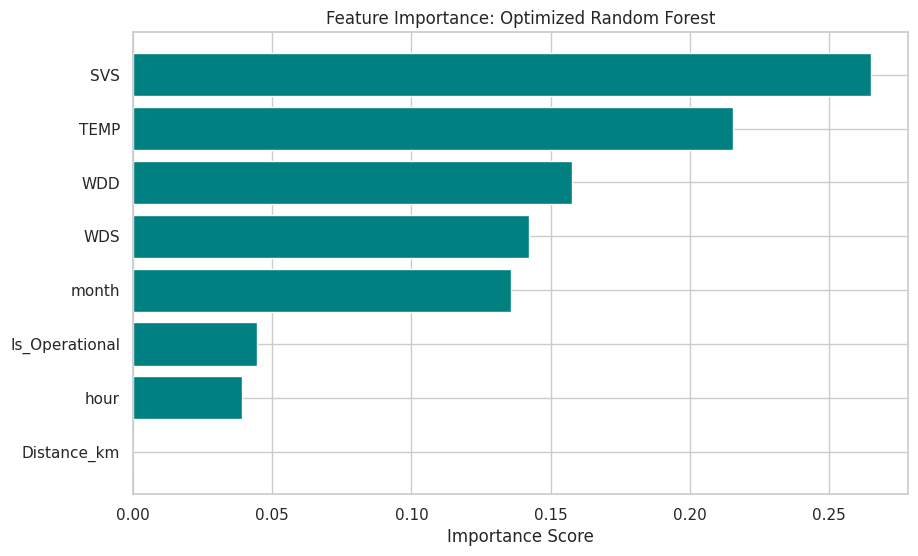

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
# ============================================================
# 39. Feature Contribution (Theta) & Performance Audit
# ============================================================
from sklearn.metrics import r2_score, mean_squared_error

# 1. חישוב תרומת פיצ'רים (Theta Coefficients) למודל הליניארי
theta_df = pd.DataFrame({
    'Feature': features,
    'Theta (Coefficient)': lr.coef_
}).sort_values(by='Theta (Coefficient)', ascending=False)

print("--- Linear Regression Feature Contribution (Theta) ---")
display(theta_df)

# 2. פונקציה להערכת ביצועים (אימון מול מבחן) והשוואה לסטיית התקן (RMSE vs STD)
y_mean = y.mean()
y_std = y.std()

def audit_model(model, X_tr, X_te, y_tr, y_te, name, is_scaled=False):
    # שימוש בנתונים מנורמלים במידה והמודל דורש זאת (Neural Network)
    xtr, xte = (X_tr, X_te) if not is_scaled else (X_train_scaled, X_test_scaled)

    p_tr = model.predict(xtr)
    p_te = model.predict(xte)

    r2_tr, r2_te = r2_score(y_tr, p_tr), r2_score(y_te, p_te)
    rmse_tr, rmse_te = np.sqrt(mean_squared_error(y_tr, p_tr)), np.sqrt(mean_squared_error(y_te, p_te))

    return {
        'Model': name,
        'Train_R2': round(r2_tr, 3),
        'Test_R2': round(r2_te, 3),
        'Train_RMSE': round(rmse_tr, 2),
        'Test_RMSE': round(rmse_te, 2),
        'RMSE_to_STD_Ratio': round(rmse_te / y_std, 3)
    }

# 3. הפקת דו"ח ביצועים עבור כלל המודלים
performance_audit = [
    audit_model(lr, X_train, X_test, y_train, y_test, "Linear Regression"),
    audit_model(rf_optimized, X_train, X_test, y_train, y_test, "Random Forest"),
    audit_model(nn_mod, X_train, X_test, y_train, y_test, "Neural Network", is_scaled=True),
    audit_model(xgb_mod, X_train, X_test, y_train, y_test, "XGBoost")
]

performance_df = pd.DataFrame(performance_audit)
print(f"\nTarget Variable (O3) Statistics: Mean={y_mean:.2f}, STD={y_std:.2f}")
display(performance_df)

# 4. ויזואליזציה של חשיבות תכונות (Random Forest)
plt.figure(figsize=(10, 6))
importances = rf_optimized.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Feature Importance: Optimized Random Forest')
plt.xlabel('Importance Score')
plt.savefig('final_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ייצוא דו"ח הביצועים המורחב לאקסל
performance_df.to_excel('ML_Model_Performance_Audit.xlsx', index=False)
from google.colab import files
files.download('ML_Model_Performance_Audit.xlsx')

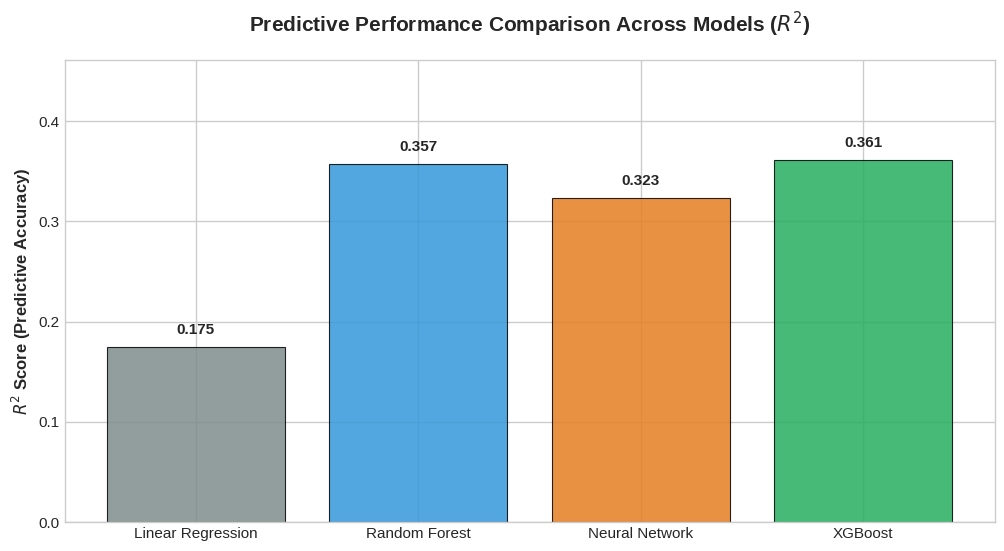

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--------------------------------------------------
Statistical analysis and model evaluation successfully archived.
Final Report: Final_Research_Model_Metrics.xlsx
Visualization: model_performance_comparison.png
--------------------------------------------------


In [90]:
# ============================================================
# 40. Comparative Analysis & Final Data Export
# ============================================================
# Final visualization of model performance metrics and archival of results.

# 1. הגדרת סגנון ויזואלי לגרף
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid') # סגנון נקי ומקצועי

# 2. יצירת גרף עמודות להשוואת R^2 (Test Set)
# אנו מושכים את הנתונים ישירות מ-performance_df של קוביה 39
colors = ['#7f8c8d', '#3498db', '#e67e22', '#27ae60'] # פלטת צבעים מקצועית
bars = plt.bar(performance_df['Model'], performance_df['Test_R2'],
               color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)

# הוספת כותרות ותוויות ציר בסגנון אקדמי
plt.ylabel('$R^2$ Score (Predictive Accuracy)', fontsize=12, fontweight='bold')
plt.title('Predictive Performance Comparison Across Models ($R^2$)', fontsize=15, fontweight='bold', pad=20)
plt.ylim(0, max(performance_df['Test_R2']) + 0.1) # מרווח עליון לתוויות

# הוספת הערך המדויק מעל כל עמודה
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# שמירה וייצוא הגרף
comparison_plot_filename = 'model_performance_comparison.png'
plt.savefig(comparison_plot_filename, dpi=300, bbox_inches='tight')
plt.show()
files.download(comparison_plot_filename)

# 3. ייצוא סופי של טבלת המדדים המורחבת (Audit Table)
# הטבלה כבר מכילה את ה-RMSE, ה-STD Ratio וה-Train/Test split
final_export_filename = 'Final_Research_Model_Metrics.xlsx'
performance_df.to_excel(final_export_filename, index=False)
files.download(final_export_filename)

print("-" * 50)
print("Statistical analysis and model evaluation successfully archived.")
print(f"Final Report: {final_export_filename}")
print(f"Visualization: {comparison_plot_filename}")
print("-" * 50)